## <center> **Loan Approval Prediction Using Random Forest** </center>
---

### Import Libraries

In [102]:
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

### Load the dataset

In [73]:
df = pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


### Shape of the data

In [74]:
df.shape

(1000, 20)

### Last five rows

In [75]:
df.tail()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes
999,1000.0,13093.0,2385.0,Salaried,23.0,Married,1.0,613.0,3.0,0.32,12436.0,25816.0,35818.0,48.0,Personal,Semiurban,Graduate,NaN,Private,No


### Basic info

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

### Columns

In [77]:
for column in df.columns:
    print(f"- {column}")

- Applicant_ID
- Applicant_Income
- Coapplicant_Income
- Employment_Status
- Age
- Marital_Status
- Dependents
- Credit_Score
- Existing_Loans
- DTI_Ratio
- Savings
- Collateral_Value
- Loan_Amount
- Loan_Term
- Loan_Purpose
- Property_Area
- Education_Level
- Gender
- Employer_Category
- Loan_Approved


### Numeric columns

In [78]:
numeric_cols = df.select_dtypes(include= ['number'])

for numeric_col in numeric_cols:
    print(f"- {numeric_col}")

- Applicant_ID
- Applicant_Income
- Coapplicant_Income
- Age
- Dependents
- Credit_Score
- Existing_Loans
- DTI_Ratio
- Savings
- Collateral_Value
- Loan_Amount
- Loan_Term


### Categorical columns

In [79]:
categorical_cols = df.select_dtypes(include= ['object'])

for categorical_col in categorical_cols:
    print(f"- {categorical_col}")

- Employment_Status
- Marital_Status
- Loan_Purpose
- Property_Area
- Education_Level
- Gender
- Employer_Category
- Loan_Approved


### Null values

In [80]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

### Percentage of null values

In [81]:
df.isnull().sum() / len(df) *100

Applicant_ID          5.0
Applicant_Income      5.0
Coapplicant_Income    5.0
Employment_Status     5.0
Age                   5.0
Marital_Status        5.0
Dependents            5.0
Credit_Score          5.0
Existing_Loans        5.0
DTI_Ratio             5.0
Savings               5.0
Collateral_Value      5.0
Loan_Amount           5.0
Loan_Term             5.0
Loan_Purpose          5.0
Property_Area         5.0
Education_Level       5.0
Gender                5.0
Employer_Category     5.0
Loan_Approved         5.0
dtype: float64

### Duplicate values

In [82]:
df.duplicated().sum()

0

- No duplicate value(s)

### Fill missing values of categorical columns

In [83]:
mode_imputer = SimpleImputer(strategy='most_frequent')

categorical_cols = df.select_dtypes(include= ['object'])

for categorical_col in categorical_cols:
    df[categorical_col] = mode_imputer.fit_transform(df[[categorical_col]]).ravel()
    print(f"Missing values successfully filled in '{categorical_col}' column")

Missing values successfully filled in 'Employment_Status' column
Missing values successfully filled in 'Marital_Status' column
Missing values successfully filled in 'Loan_Purpose' column
Missing values successfully filled in 'Property_Area' column
Missing values successfully filled in 'Education_Level' column
Missing values successfully filled in 'Gender' column
Missing values successfully filled in 'Employer_Category' column
Missing values successfully filled in 'Loan_Approved' column


### Fill missing values in Numeric columns

In [84]:
numeric_imputer = SimpleImputer(strategy='median')
numeric_cols = df.select_dtypes(include=['number'])

for numeric_col in numeric_cols:
    df[numeric_col] =  numeric_imputer.fit_transform(df[[numeric_col]]).ravel()
    print(f"Missing values successfully filled in '{numeric_col}' column")

Missing values successfully filled in 'Applicant_ID' column
Missing values successfully filled in 'Applicant_Income' column
Missing values successfully filled in 'Coapplicant_Income' column
Missing values successfully filled in 'Age' column
Missing values successfully filled in 'Dependents' column
Missing values successfully filled in 'Credit_Score' column
Missing values successfully filled in 'Existing_Loans' column
Missing values successfully filled in 'DTI_Ratio' column
Missing values successfully filled in 'Savings' column
Missing values successfully filled in 'Collateral_Value' column
Missing values successfully filled in 'Loan_Amount' column
Missing values successfully filled in 'Loan_Term' column


### Check missing values after filling

In [85]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### Drop `Applicant ID` column 

In [86]:
df.drop('Applicant_ID', axis= 1, inplace=True)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


### Total Applicants by Gender

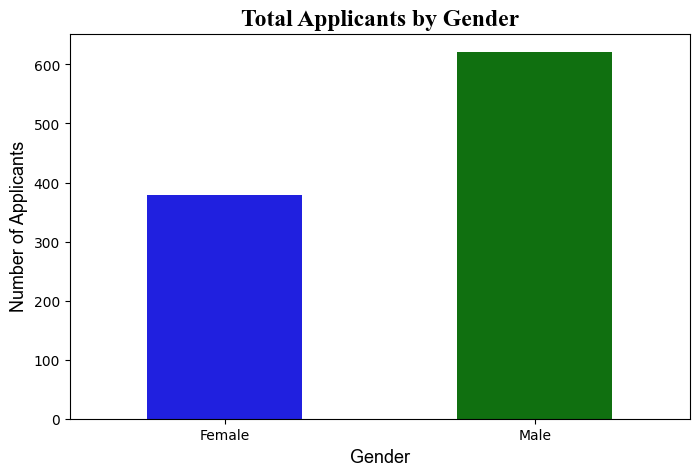

In [88]:
plt.figure(figsize=(8, 5))
sns.countplot(x= df['Gender'], palette=["blue", "green"], width=0.5)

title_font = {"family": "Times New Roman", "weight": "bold", "size": 17, "color": "black"}
label_font = {"family": "Arial", "size": 13, "color": "black"}

plt.title("Total Applicants by Gender", fontdict=title_font)
plt.xlabel("Gender", fontdict= label_font)
plt.ylabel("Number of Applicants", fontdict= label_font)
plt.show()

##### **Insights:**
- Male applicants axceed 600, substantially higher than female applicants at around 380.
- Males account for roughly 62% of total applicants, showing a notable imablance in gender participation.

### Approved Loan by Gender

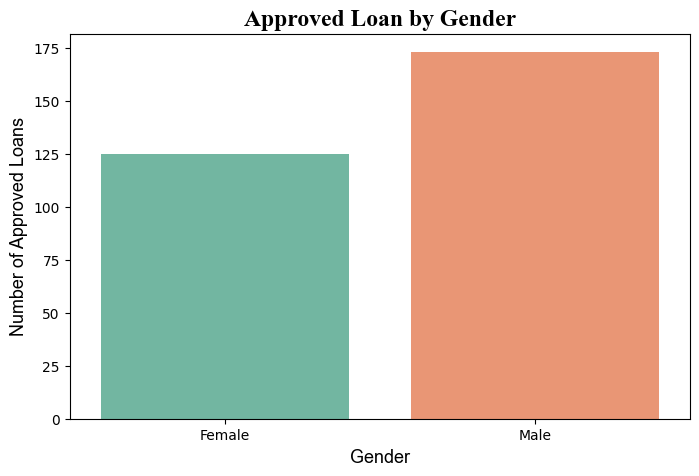

In [89]:
approved_loan = df[df['Loan_Approved'] == 'Yes'].groupby('Gender')['Loan_Approved'].count()

plt.figure(figsize=(8, 5))
sns.barplot(x= approved_loan.index, y= approved_loan.values, palette='Set2')

title_font = {"family": "Times New Roman", "weight": "bold", "size": 17, "color": "black"}
label_font = {"family": "Arial", "size": 13, "color": "black"}

plt.title("Approved Loan by Gender", fontdict=title_font)
plt.xlabel("Gender", fontdict= label_font)
plt.ylabel("Number of Approved Loans", fontdict= label_font)
plt.show()

##### **Insights:**
- Males have more approved loans at around 175, compared to females at around 125. 
- Male approvals are roughly 34% higher than females approvals, reflecting a continued gap in loan approvals by gender.

### Percentage of Approved Loan by Gender

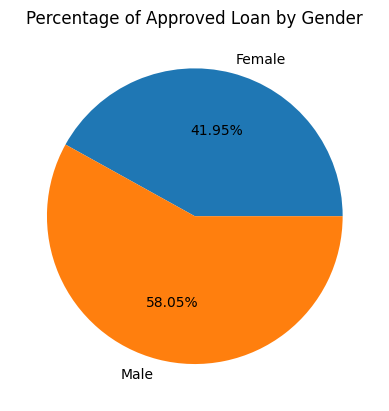

In [90]:
plt.pie(
    x= approved_loan.values,
    labels= approved_loan.index,
    autopct= "%.2f%%"
)

plt.title("Percentage of Approved Loan by Gender")
plt.show()

##### **Insights:**
- Males hold 58.05% of approved loans, making up the larger share of approvals.
- Female approved loans account for 41.95%, showing a 16.1% gap compared to male approvals.

### Not Approved Loan by Gender

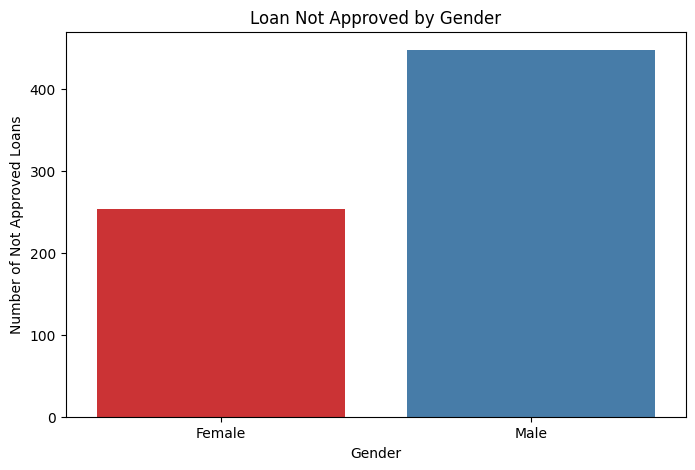

In [91]:
not_approved_loan = df[df['Loan_Approved'] == "No"].groupby("Gender")["Loan_Approved"].count()

plt.figure(figsize=(8, 5))
sns.barplot(x= not_approved_loan.index, y=not_approved_loan.values, palette="Set1")

plt.title("Loan Not Approved by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Not Approved Loans")
plt.show()

##### **Insights:**
- Males have significantly more unapproved loans at around 425, compared to females at around 250.

### Percentage of Not Approved Loan by Gender

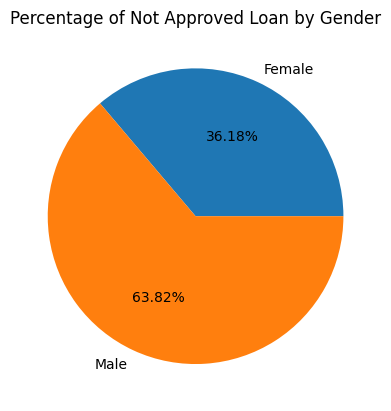

In [92]:
plt.pie(
    x= not_approved_loan.values,
    labels= not_approved_loan.index,
    autopct= "%.2f%%"
)
plt.title("Percentage of Not Approved Loan by Gender")
plt.show()

##### **Insights:**
- Males account for 63.82% of all not approved loans, comapred to 36.18% for females.
- This gap is expected since the dataset contains more male applicants overall. 

### Loan Approved by Marital_Status

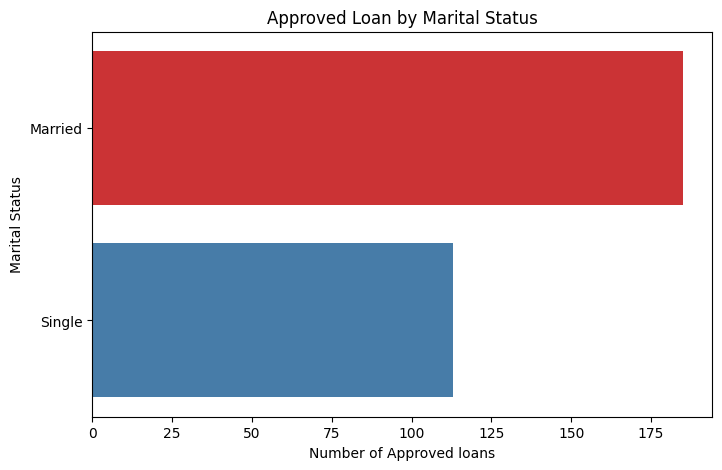

In [93]:
approved_loan = df[df["Loan_Approved"] == "Yes"].groupby("Marital_Status")["Loan_Approved"].count()

plt.figure(figsize= (8, 5))
sns.barplot(
    x= approved_loan.values,
    y= approved_loan.index,
    palette= "Set1"
)

plt.title("Approved Loan by Marital Status")
plt.xlabel("Number of Approved loans")
plt.ylabel("Marital Status")
plt.show()

##### **Insights:**
- Married applicants have 180 approved loans vs 110 for single applicants.

### Percentage of Approved Loans by Marital Status

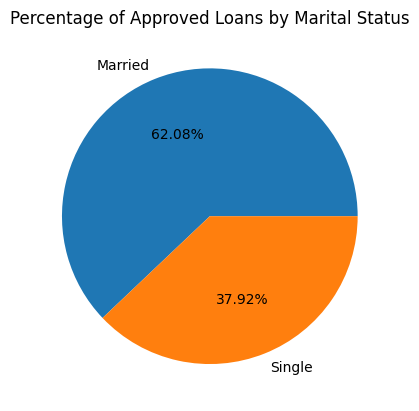

In [94]:
plt.pie(
    x= approved_loan.values,
    labels= approved_loan.index,
    autopct= "%.2f%%"
)

plt.title("Percentage of Approved Loans by Marital Status")
plt.show()

##### **Insights:**
- 62% of all approved loans went to married applicants vs 37% for single applicants.

### Loan Not Approved by Marital Status

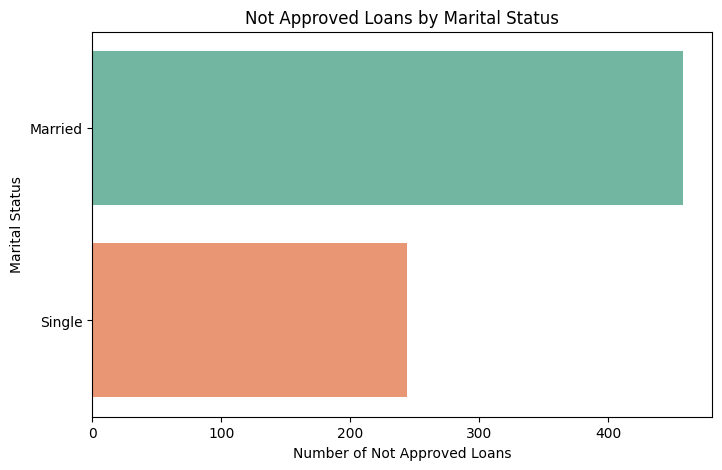

In [95]:
not_approved_loan = df[df["Loan_Approved"] == "No"].groupby("Marital_Status")["Loan_Approved"].count()

plt.figure(figsize=(8, 5))
sns.barplot(
    x= not_approved_loan.values,
    y= not_approved_loan.index,
    palette= "Set2"
)

plt.xlabel("Number of Not Approved Loans")
plt.ylabel("Marital Status")
plt.title("Not Approved Loans by Marital Status")
plt.show()

#### **Insights:**
- Married applicants have 400 not approved loans, significantly more than Single applicants.
- Married applicants also had more approvals earlier. This suggests they are simply the larger group in the dataset overall

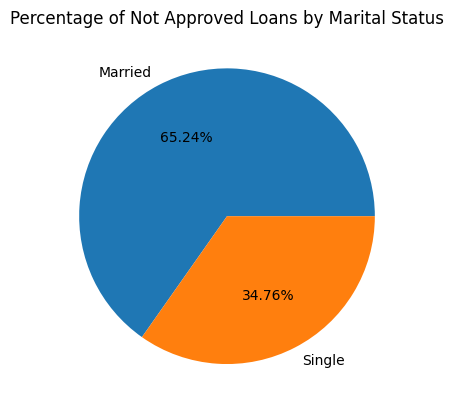

In [25]:
plt.pie(
    x= not_approved_loan.values,
    labels= not_approved_loan.index,
    autopct= "%.2f%%"
)

plt.title("Percentage of Not Approved Loans by Marital Status")
plt.show()

##### **Insights:**
- 65% of all not approved loans belong to married applicants vs 34% for single applicants. 

### Age distribution

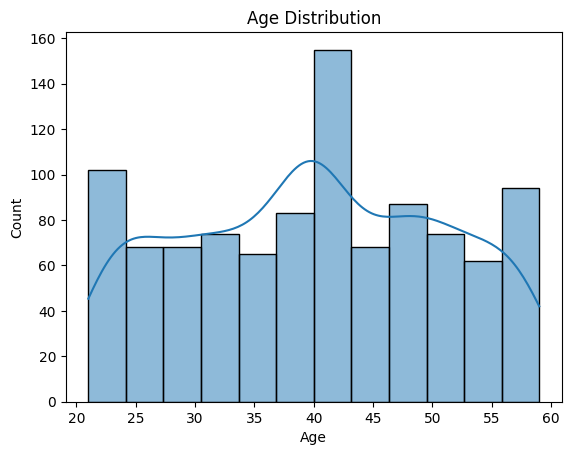

In [26]:
sns.histplot(
    x= df["Age"],
    bins= 12,
    kde= True
)
plt.title("Age Distribution")
plt.show()

##### **Insights:**
- Applicants around age 40 are the large group with 155 applicants.
- Showing broad age diversity in loan applications.

### Approved Loan by Employment Status

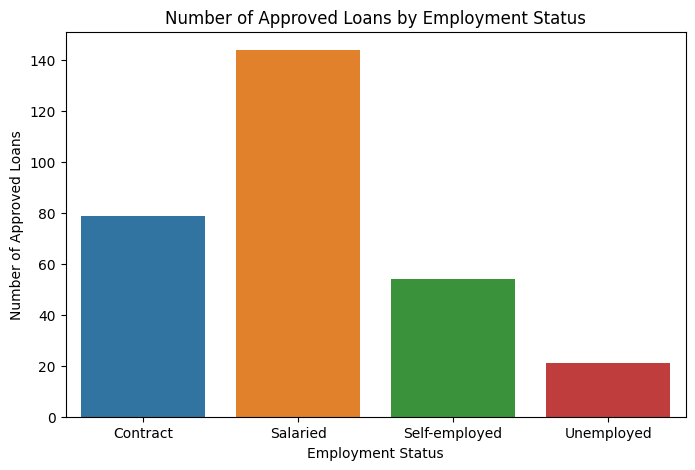

In [27]:
plt.figure(figsize= (8, 5))
approved_loan = df[df["Loan_Approved"] == "Yes"].groupby("Employment_Status")["Loan_Approved"].count()

sns.barplot(
    x= approved_loan.index,
    y= approved_loan.values
)

plt.xlabel("Employment Status")
plt.ylabel("Number of Approved Loans")
plt.title("Number of Approved Loans by Employment Status")
plt.show()

##### **Insights:**
- Salaried workers have 145 approved loans, nearly 2x more than the next group.
- Contract employees get 80 approvals, showing stable income helps but less than salaried.
- Self-employed 55 and Unemployed 20 approvals, likely due to perceived income instability.

### Percentage of Approved Loans by Employment Status

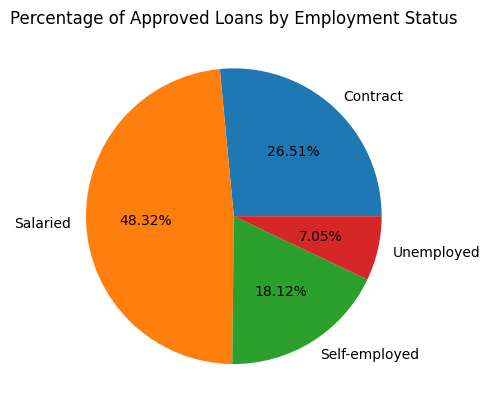

In [28]:
plt.pie(
    x= approved_loan.values,
    labels= approved_loan.index,
    autopct= "%.2f%%"
)

plt.title("Percentage of Approved Loans by Employment Status")
plt.show()

##### **Insights:**
- 48% of all approved loans go to salaried applicants, almost half of total applicants.
- Contract workers make up 26.51% of approvals, about half the share of salaried

### Not Approved Loans by Employement Status

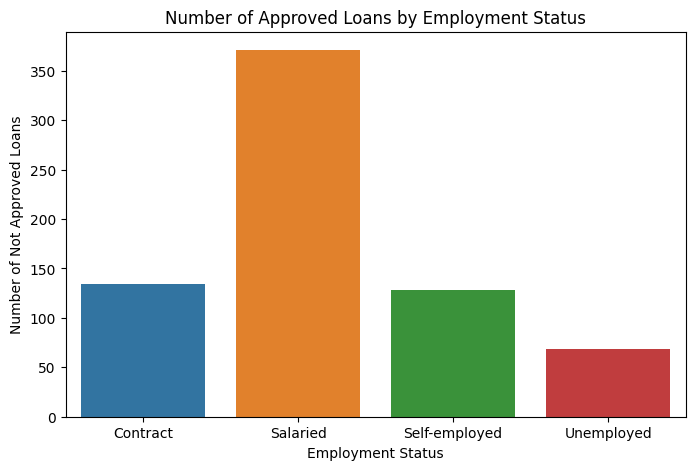

In [29]:
plt.figure(figsize= (8, 5))
not_approved_loan = df[df["Loan_Approved"] == "No"].groupby("Employment_Status")["Loan_Approved"].count()

sns.barplot(
    x= not_approved_loan.index,
    y= not_approved_loan.values
)

plt.xlabel("Employment Status")
plt.ylabel("Number of Not Approved Loans")
plt.title("Number of Approved Loans by Employment Status")
plt.show()

##### **Insights:**
- 370 not approved loans, for higher any other group.
- Both have 120-130 rejections, much lower than salaried but still significant

### Percentage of Not Approved Loans by Employment Status

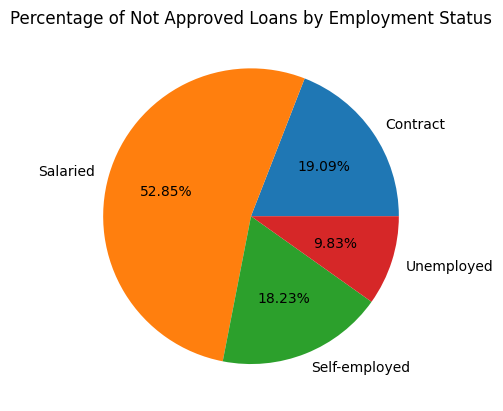

In [30]:
plt.pie(
    x= not_approved_loan.values,
    labels= not_approved_loan.index,
    autopct= "%.2f%%"
)

plt.title("Percentage of Not Approved Loans by Employment Status")
plt.show()

##### **Insights:**
- 52.85% of all approved loans are from salaried applicants, over half the total.

### Distribution of Applicant Income

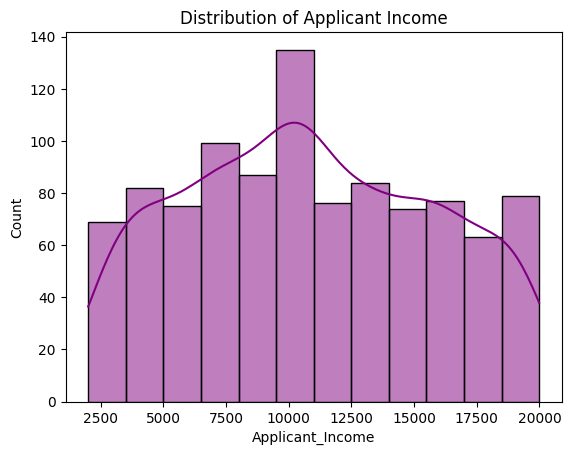

In [31]:
sns.histplot(
    x= df['Applicant_Income'],
    kde= True,
    color= "purple"
)

plt.title("Distribution of Applicant Income")
plt.show()

##### **Insights:**
- Most applicants fall in the 10,000 income bracket with 130 applicants, the highest count.
- Srong applicant count also ground 7,500 and 5,000 each with 80-100 applicants.

### Credit Score Distribution by Loan Status

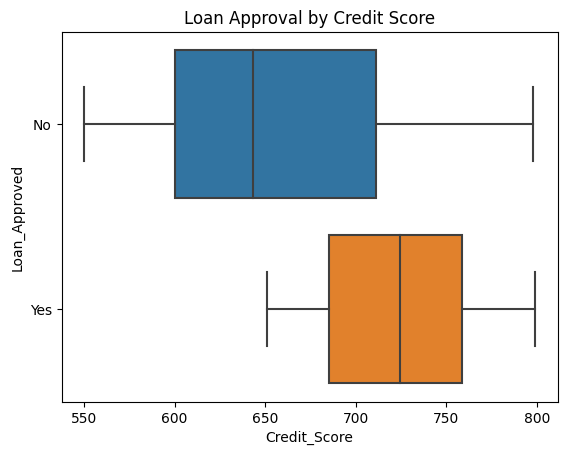

In [98]:
sns.boxplot(
    x= df["Credit_Score"],
    y= df["Loan_Approved"],
    orient= "horizontal"
)

plt.title("Loan Approval by Credit Score")
plt.show()

##### **Insights:**
- Approved loans have a median credit score 175 vs 650 for not approved.
- 75% of approved loans have credit scores above 685. For not approved, 75% are below 700

### Applicant Income vs Loan Approved

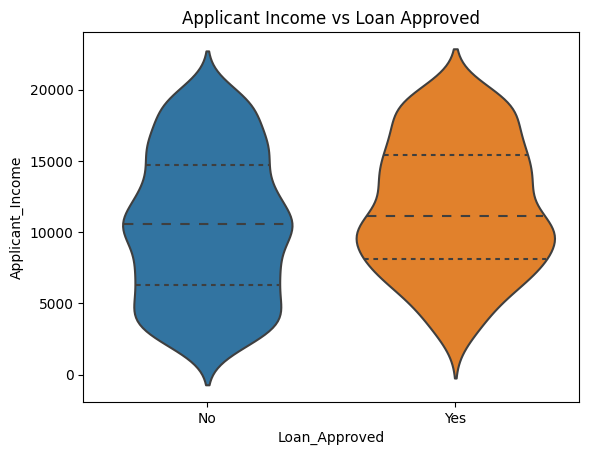

In [33]:
sns.violinplot(
    x= df["Loan_Approved"],
    y= df["Applicant_Income"],
    inner= "quartile"
)

plt.title("Applicant Income vs Loan Approved")
plt.show()

##### **Insights:**
- Both approved and not approved loans span 0 to 20,000 income. High income does not guarantee approval

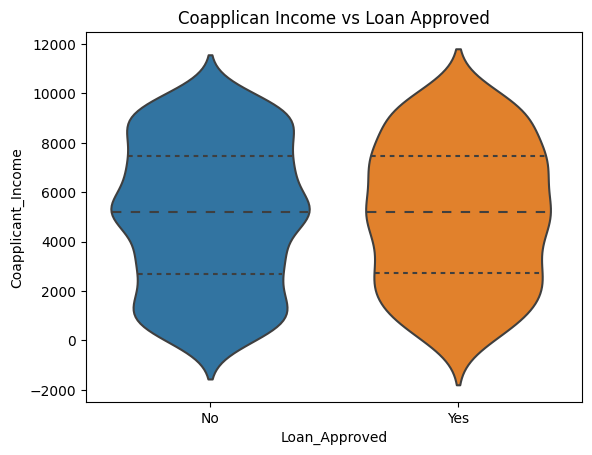

In [34]:
sns.violinplot(
    x= df["Loan_Approved"],
    y= df["Coapplicant_Income"],
    inner= "quartile"
)

plt.title("Coapplican Income vs Loan Approved")
plt.show()

##### **Insights:**
- Co-applicants income for approved vs not approved loans has nearly the same range 0 to 11,000

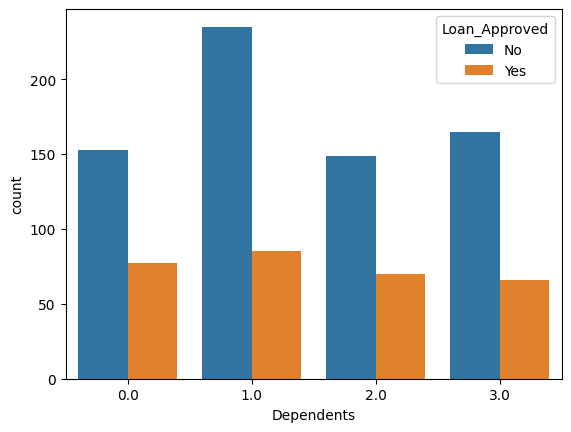

In [35]:
sns.countplot(
    x= df["Dependents"],
    hue= df["Loan_Approved"]
)

plt.show()

##### **Insights:**
- No bars are 2-3x higher than Yes for every dependents level.

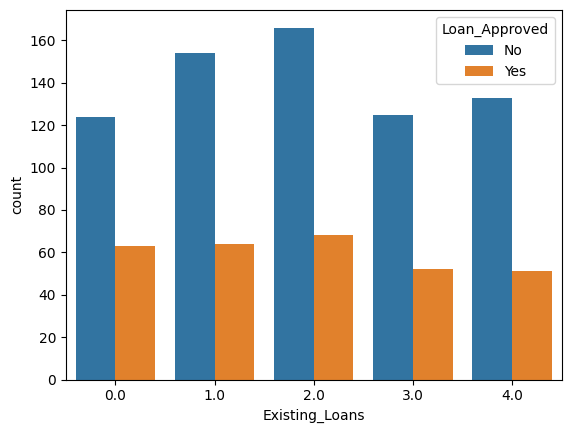

In [36]:
sns.countplot(
    x= df["Existing_Loans"],
    hue= df["Loan_Approved"]
)

plt.show()

##### **Insights:**
- Blue No bars are 2-3x higher than orange Yes bars across all dependent counts.

### Loan Approved based on Property Area

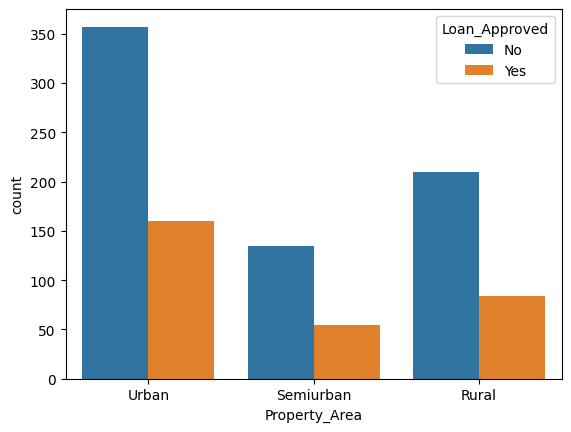

In [37]:
sns.countplot(
    x= df["Property_Area"],
    hue= df["Loan_Approved"]
)

plt.show()

##### **Insights:**
- Most applicants and rejections come from Urban 360 No vs 160 Yes

### Loan Approved based on Employe Category

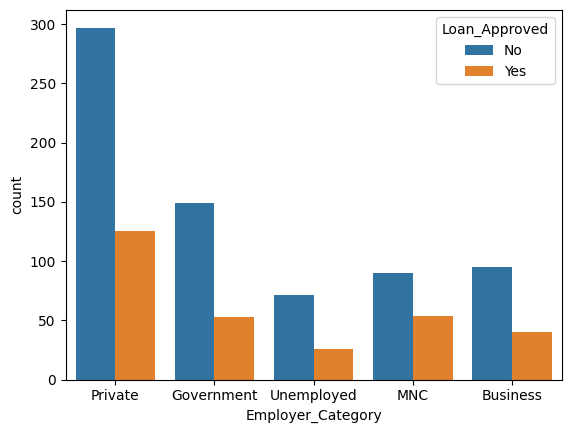

In [38]:
sns.countplot(
    x= df["Employer_Category"],
    hue= df["Loan_Approved"]
)

plt.show()

##### **Insights:**
- Most applicants and rejections come from Private Employees, 300 No vs 125 Yes

#### Loan Approved based on Education Level

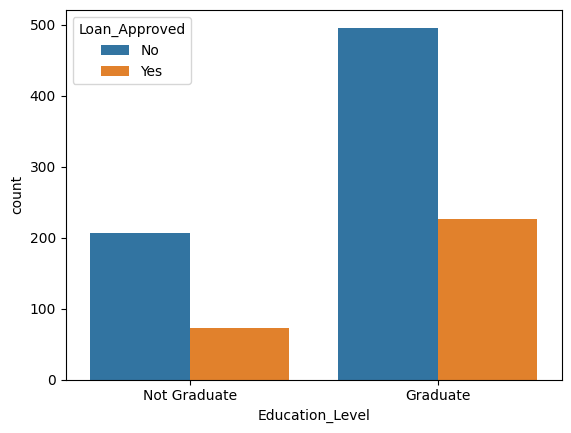

In [39]:
sns.countplot(
    x= df["Education_Level"],
    hue= df["Loan_Approved"]
)

plt.show()

##### **Insights:**
- Most loan applicants come from Graduate 500 No 210 Yes 710 total

- Convert Loan_Approved Column into Numeric so that we can see its coorelation with other features

In [41]:
df["Loan_Approved"] = df["Loan_Approved"].map({"Yes": 1, "No": 0})

### Correlation Heatmap

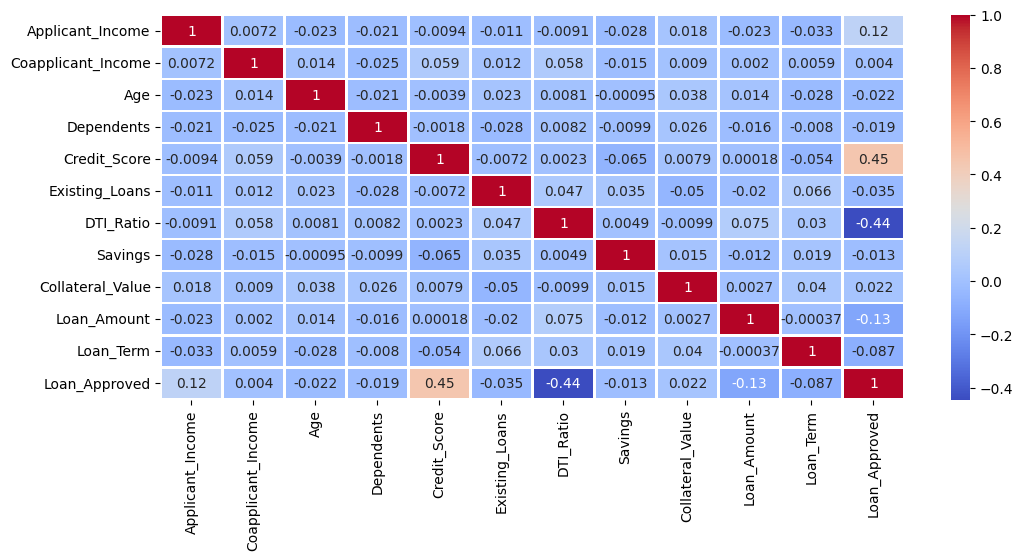

In [42]:
corr = df.corr()

plt.figure(figsize= (12, 5))
sns.heatmap(
    corr,
    annot= True,
    cmap= "coolwarm",
    linewidths=1
)

plt.show()

##### **Insights:**
- Credit Score is strongest positive driver
- DTI Ratio is also strongest driver

#### **Most Important Features**
- Credit_Score (0.45)
- DTI_Ratio (-0.44)
- Loan_Amount (0.13) (moderately useful)
- Applicabt_Income (0.12) (moderately useful)

#### **Remember That**

We do not drop features based only on correlation. Some features:
- Can have non-linear relationships
- Can be useful in combination

Tree-based models like Random Forest and XGBoost can detect their importance even if correlation is low.

#### Convert Categorical columns into Numeric

In [43]:
df["Employment_Status"] = df["Employment_Status"].map({
    "Salaried": 1,
    "Self-employed": 2,
    "Contract": 3,
    "Unemployed": 0
})

df["Marital_Status"] = df["Marital_Status"].map({
    "Married": 1,
    "Single": 0
})

df["Loan_Purpose"] = df["Loan_Purpose"].map({
    "Personal": 1,
    "Car": 2,
    "Business": 3,
    "Home": 4,
    "Education": 5
})

df["Property_Area"] = df["Property_Area"].map({
    "Urban": 1,
    "Semiurban": 2,
    "Rural": 0
})

df["Education_Level"] = df["Education_Level"].map({
    "Not Graduate": 0,
    "Graduate": 1
})

df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

df["Employer_Category"] = df["Employer_Category"].map({
    "Private": 2,
    "Unemployed": 0,
    "Government": 4,
    "MNC": 3,
    "Business": 1
})

### Features and Target

In [44]:
X = df.drop("Loan_Approved", axis= 1)
y = df["Loan_Approved"]

### Train and Test Set

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.3,
    random_state= 42,
    shuffle= True
)

### Train Model

In [46]:
model = RandomForestClassifier(
    n_estimators= 400,
    random_state= 42,
    min_samples_split=5
)
model.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=5, n_estimators=400, random_state=42)

### Predictions

In [60]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(y_pred)

[0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0
 1 0 0 0 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1
 1 0 0 1 0 1 1 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 1 0 0 1 0
 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 0 0 0
 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 0 0
 0 0 0 0]


### Evaluation

In [61]:
print(classification_report(y_test, y_pred, target_names=['Not Approved', 'Approved']))

              precision    recall  f1-score   support

Not Approved       0.93      0.94      0.94       202
    Approved       0.88      0.86      0.87        98

    accuracy                           0.91       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.91      0.91      0.91       300



### Confusion Matrix & ROC Curve

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

### Save Model with Scaler

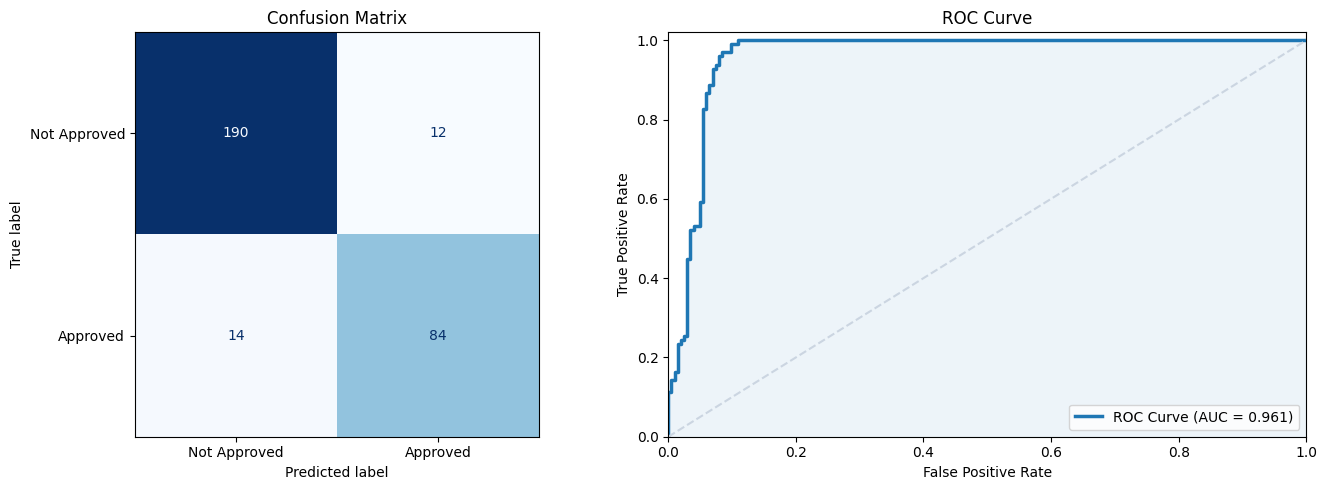

AUC Score: 0.9607


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm   = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Approved', 'Approved'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='#CBD5E1', lw=1.5)
axes[1].fill_between(fpr, tpr, alpha=0.08)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()
print(f'AUC Score: {roc_auc:.4f}')

### Feature Importance

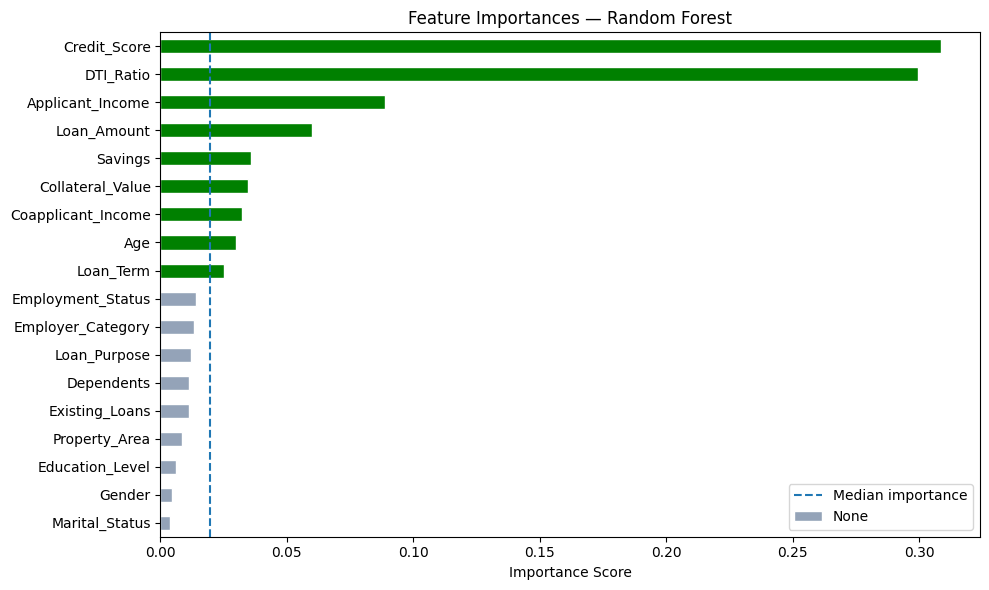


Top 5 Features:
  Credit_Score              0.3087
  DTI_Ratio                 0.2997
  Applicant_Income          0.0889
  Loan_Amount               0.0599
  Savings                   0.0357


In [66]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["Green" if v > importances.median() else '#94A3B8'
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(importances.median(),
           linestyle='--', linewidth=1.5, label='Median importance')
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 Features:')
top5 = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
for feat, score in top5.items():
    print(f'  {feat:<25} {score:.4f}')

### Save Model

In [49]:
joblib.dump(model, "model.pkl")

['model.pkl']